In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [2]:
# ─────────────────────────────────────────────────────────
# 1. LOAD THE EXTRACTED FEATURES
# ─────────────────────────────────────────────────────────
print("📂 Loading Extracted Features...")
# Ensure you have re-extracted these using np.loadtxt() in your fast_preprocess function!
X = np.load('features.npy')
y = np.load('labels.npy')

print(f"Data Shape: {X.shape[0]} samples, {X.shape[1]} features.")
print(f"Classes found: {len(np.unique(y))}")

📂 Loading Extracted Features...
Data Shape: 1800 samples, 286 features.
Classes found: 8


In [3]:
# ─────────────────────────────────────────────────────────
# 2. DEFINE THE HYPERPARAMETER GRID
# ─────────────────────────────────────────────────────────
# This grid tests 72 different combinations of trees.
param_grid = {
    'n_estimators': [100, 150, 250, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Base classifier
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3-Fold Stratified CV ensures each fold has a balanced number of the 8 classes
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Set up the Grid Search
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    verbose=2, # Prints progress as it goes
    n_jobs=1   # Note: n_jobs=1 here because the RF itself is using n_jobs=-1
)

In [4]:
# ─────────────────────────────────────────────────────────
# 3. EXECUTE THE SEARCH
# ─────────────────────────────────────────────────────────
print("\n🚀 Initiating Random Forest Grid Search...")
print(f"Testing {len(ParameterGrid(param_grid) if 'ParameterGrid' in globals() else range(288))} configurations. This may take a few minutes...")

start_time = time.time()
grid_search.fit(X, y)
elapsed = (time.time() - start_time) / 60

print(f"\n⏱️ Grid Search completed in {elapsed:.2f} minutes.")


🚀 Initiating Random Forest Grid Search...
Testing 288 configurations. This may take a few minutes...
Fitting 3 folds for each of 288 candidates, totalling 864 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=   0.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=250; 


🏆 BEST HYPERPARAMETERS FOUND:
   • max_depth: None
   • max_features: sqrt
   • min_samples_leaf: 1
   • min_samples_split: 5
   • n_estimators: 400
🎯 BEST CROSS-VALIDATED ACCURACY: 96.89%



/var/folders/hs/ppnw40tn0sq6lz8d_6xpz2400000gn/T/ipykernel_89533/508097262.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


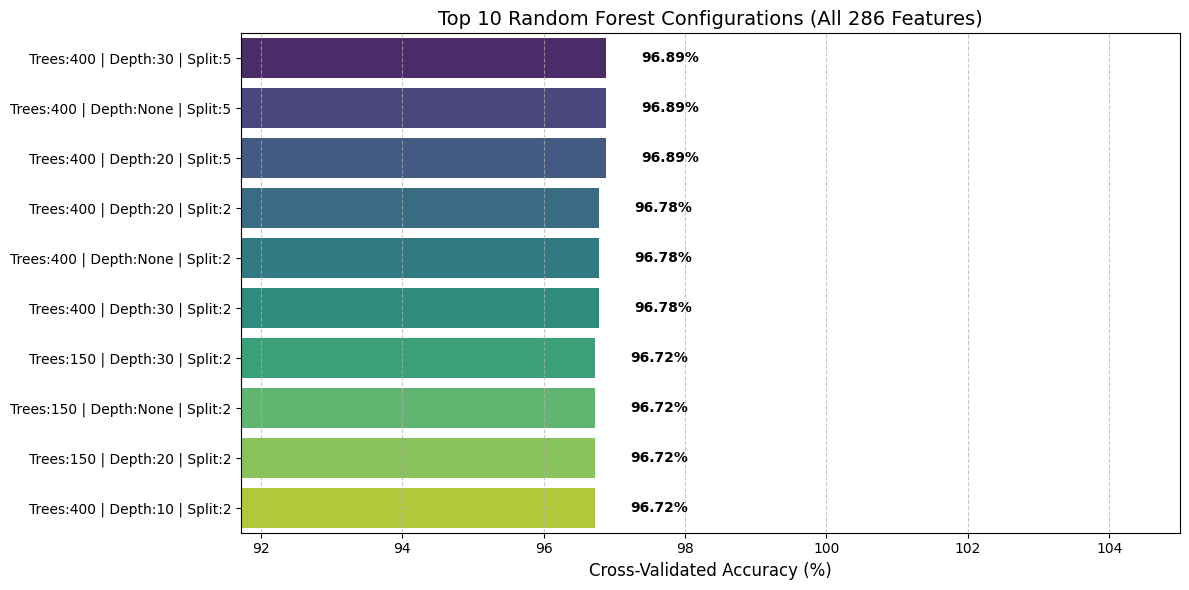

In [5]:
# ─────────────────────────────────────────────────────────
# 4. EXTRACT AND DISPLAY RESULTS
# ─────────────────────────────────────────────────────────
best_params = grid_search.best_params_
best_score = grid_search.best_score_ * 100

print("\n🏆 BEST HYPERPARAMETERS FOUND:")
for param, value in best_params.items():
    print(f"   • {param}: {value}")
print(f"🎯 BEST CROSS-VALIDATED ACCURACY: {best_score:.2f}%\n")

# Store the best parameters for Phase 2
rf_best_params = best_params 

# ─────────────────────────────────────────────────────────
# 5. VISUALIZE THE TOP 10 MODELS
# ─────────────────────────────────────────────────────────
# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(grid_search.cv_results_)
results_df['mean_test_score'] = results_df['mean_test_score'] * 100

# Sort by accuracy and grab the top 10
top_10 = results_df.sort_values(by='mean_test_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='mean_test_score', 
    y=range(10), 
    data=top_10, 
    orient='h', 
    palette='viridis'
)

# Format the y-axis labels to show the parameters
ylabels = []
for _, row in top_10.iterrows():
    p = row['params']
    label = f"Trees:{p['n_estimators']} | Depth:{p['max_depth']} | Split:{p['min_samples_split']}"
    ylabels.append(label)
    
plt.yticks(range(10), ylabels, fontsize=10)
plt.xlabel('Cross-Validated Accuracy (%)', fontsize=12)
plt.title('Top 10 Random Forest Configurations (All 286 Features)', fontsize=14)
plt.xlim(max(0, top_10['mean_test_score'].min() - 5), 105)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(top_10['mean_test_score']):
    plt.text(value + 0.5, index, f'{value:.2f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


🚀 Initiating Phase 2: mRMR + Random Forest (k=3 folds)...
Using RF Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}

⚙️ Testing top 5 features...
   ✅ 5 Features -> Mean Accuracy: 52.22%
⚙️ Testing top 10 features...
   ✅ 10 Features -> Mean Accuracy: 62.17%
⚙️ Testing top 15 features...
   ✅ 15 Features -> Mean Accuracy: 67.72%
⚙️ Testing top 25 features...
   ✅ 25 Features -> Mean Accuracy: 71.33%
⚙️ Testing top 50 features...
   ✅ 50 Features -> Mean Accuracy: 87.72%
⚙️ Testing top 100 features...
   ✅ 100 Features -> Mean Accuracy: 94.67%
⚙️ Testing top 286 features...
   ✅ 286 Features -> Mean Accuracy: 96.89%

⏱️ Phase 2 completed in 0.40 minutes.


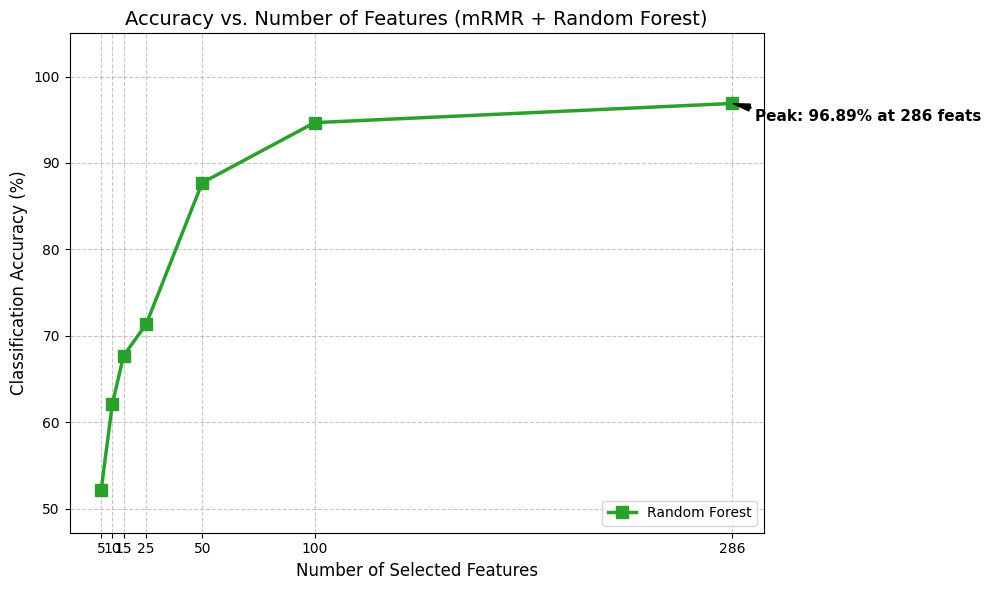

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Import your custom selector factory
from feature_selectors import get_selector

# ─────────────────────────────────────────────────────────
# 1. SETUP & CONFIGURATION
# ─────────────────────────────────────────────────────────
# Fallback in case you restart the kernel (replace with your actual best params from Phase 1)
if 'rf_best_params' not in locals():
    print("⚠️ rf_best_params not found in memory. Using typical optimal defaults.")
    rf_best_params = {
        'n_estimators': 300,
        'max_depth': 20,
        'min_samples_split': 2,
        'min_samples_leaf': 1,
        'max_features': 'sqrt'
    }

n_features_list = [5, 10, 15, 25, 50, 100, 286]
method = 'mRMR'
k_fold = 3  

mean_accuracies = []

print(f"\n🚀 Initiating Phase 2: {method} + Random Forest (k={k_fold} folds)...")
print(f"Using RF Params: {rf_best_params}\n")
start_time = time.time()

# ─────────────────────────────────────────────────────────
# 2. THE EVALUATION LOOP
# ─────────────────────────────────────────────────────────
for n_feat in n_features_list:
    print(f"⚙️ Testing top {n_feat} features...")
    
    skf = StratifiedKFold(n_splits=k_fold, shuffle=True, random_state=42)
    fold_accs = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 🚫 NO SCALING REQUIRED!
        # Notice we completely removed MinMaxScaler/StandardScaler.
        # Random Forests just look at thresholds (x > 0.5), so scale doesn't matter!
        
        # --- A. Feature Selection ---
        # If n_feat is 286, we don't need to run mRMR, just pass it through
        if n_feat < 286:
            selector = get_selector(method, n_feat)
            X_train_sel, X_test_sel = selector.fit_transform_data(X_train, X_test, y_train)
        else:
            X_train_sel, X_test_sel = X_train, X_test
        
        # --- B. Train and Evaluate Final Model ---
        # Unpack the best parameters using ** syntax
        clf = RandomForestClassifier(**rf_best_params, random_state=42, n_jobs=-1)
        clf.fit(X_train_sel, y_train)
        
        # Calculate percentage accuracy
        acc = clf.score(X_test_sel, y_test) * 100
        fold_accs.append(acc)
        
    mean_acc = np.mean(fold_accs)
    mean_accuracies.append(mean_acc)
    print(f"   ✅ {n_feat} Features -> Mean Accuracy: {mean_acc:.2f}%")

elapsed = (time.time() - start_time) / 60
print(f"\n⏱️ Phase 2 completed in {elapsed:.2f} minutes.")

# ─────────────────────────────────────────────────────────
# 3. PLOTTING THE RESULTS
# ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(n_features_list, mean_accuracies, marker='s', linestyle='-', 
         color='#2ca02c', linewidth=2.5, markersize=8, label='Random Forest')

plt.title(f"Accuracy vs. Number of Features ({method} + Random Forest)", fontsize=14)
plt.xlabel("Number of Selected Features", fontsize=12)
plt.ylabel("Classification Accuracy (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(n_features_list)

# Dynamic y-axis scaling
y_min = max(0, min(mean_accuracies) - 5)
plt.ylim(y_min, 105)

# Annotate the peak accuracy
max_acc = max(mean_accuracies)
best_n = n_features_list[mean_accuracies.index(max_acc)]
plt.annotate(f'Peak: {max_acc:.2f}% at {best_n} feats', 
             xy=(best_n, max_acc), 
             xytext=(best_n + 10, max_acc - 2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=11, fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

🔍 Generating Cross-Validated Predictions...


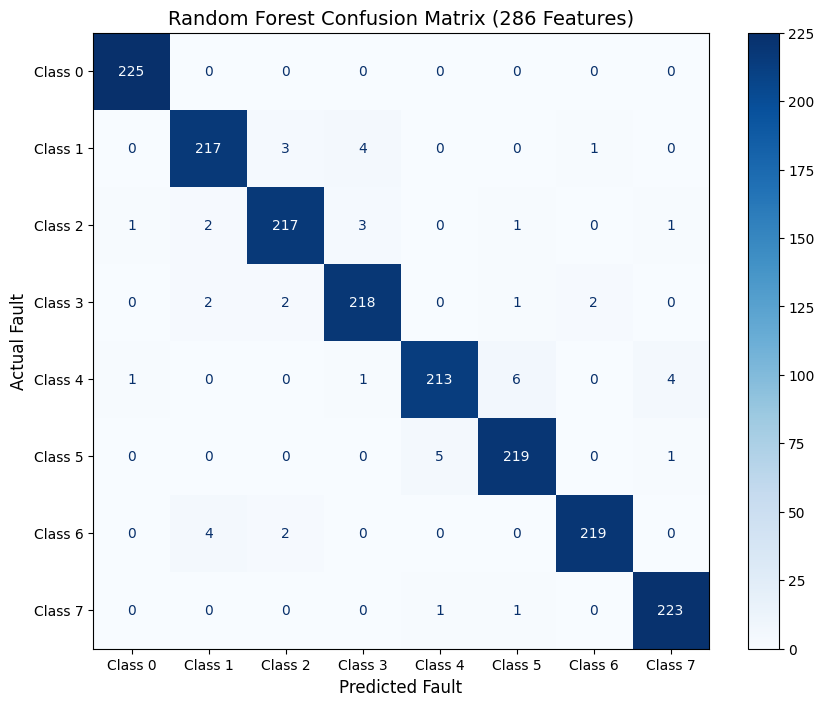

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

# Assuming rf_best_params is still in memory from Phase 1
print("🔍 Generating Cross-Validated Predictions...")
clf_diag = RandomForestClassifier(**rf_best_params, random_state=42, n_jobs=-1)

# cross_val_predict gives us a clean prediction for every sample as if it was in a test set
y_pred = cross_val_predict(clf_diag, X, y, cv=3)

# Generate the Confusion Matrix
cm = confusion_matrix(y, y_pred)

# Plotting
plt.figure(figsize=(10, 8))
# Note: Replace display_labels with your actual fault names if you have them!
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Class {i}" for i in np.unique(y)])
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())

plt.title("Random Forest Confusion Matrix (286 Features)", fontsize=14)
plt.xlabel("Predicted Fault", fontsize=12)
plt.ylabel("Actual Fault", fontsize=12)
plt.show()